In [6]:
#Part 1 of the code takes wavelength and intensity values measured with a spectrometer (HR2000_file) and optic fibre (of either 100um or 400um)
#and compares these values to the known values (lamp_file) for the light source (halogen-tungsten lamp) in order to find the calibration factor

In [7]:
#import necessary python libraries

import matplotlib.pyplot as plt
import numpy as np
from itertools import islice

In [ ]:
#call files (only the HR2000_file needs to be changed for either the 100um or 400um optic fibre)

lamp_file = 'lamp.txt'#known lamp file
HR2000_file = r'HR2000_100_w_lens_HRC21401__0__12-36-18-456 (1).txt'#measured calibration data
# Construct Correction_file path in a more reliable way
Correction_file = f'empty.rtf'

In [9]:
import numpy as np

# Remove these initializations - they're setting your data to 0!
# lamp_Wavelengths = 0
# lamp_Intensities = 0  
# Wavelengths = 0
# Intensities = 0

def calculate_calibration(Wavelengths, Intensities, lamp_Wavelengths, lamp_Intensities):
    # Filter data to a range of 350 nm to 800 nm
    filtered_indices = [i for i, w in enumerate(Wavelengths) if 350 <= w <= 800]
    Wavelengths = [Wavelengths[i] for i in filtered_indices]
    Intensities = [Intensities[i] for i in filtered_indices]

    filtered_lamp_indices = [i for i, w in enumerate(lamp_Wavelengths) if 350 <= w <= 800]
    lamp_Wavelengths = [lamp_Wavelengths[i] for i in filtered_lamp_indices]
    lamp_Intensities = [lamp_Intensities[i] for i in filtered_lamp_indices]

    # Sort the HR2000 data by wavelength
    sorted_indices = np.argsort(Wavelengths)
    sorted_HR2000_wavelengths = np.array(Wavelengths)[sorted_indices]
    sorted_HR2000_intensities = np.array(Intensities)[sorted_indices]

    wavelengths = []
    calibration_factors = []
    interpolated_HR2000_intensities = []

    for i, lamp_wavelength in enumerate(lamp_Wavelengths):
        lamp_intensity = lamp_Intensities[i]

        # Check if lamp wavelength is within the HR2000 wavelength range
        if not (sorted_HR2000_wavelengths[0] <= lamp_wavelength <= sorted_HR2000_wavelengths[-1]):
            continue

        # Interpolate HR2000 intensity at lamp wavelength
        HR2000_intensity = np.interp(lamp_wavelength, sorted_HR2000_wavelengths, sorted_HR2000_intensities)

        if HR2000_intensity == 0:
            calibration_factor = float('nan')
        else:
            calibration_factor = lamp_intensity / HR2000_intensity
            if calibration_factor < 0:
                continue

        wavelengths.append(lamp_wavelength)
        interpolated_HR2000_intensities.append(HR2000_intensity)
        calibration_factors.append(calibration_factor)

    # REMOVED THE RECURSIVE CALL - this was causing infinite recursion
    return wavelengths, interpolated_HR2000_intensities, calibration_factors  # Fixed the return statement

In [10]:
# Plotting the raw data from lamp_file and HR2000_file
plt.figure(figsize=(10, 5))
plt.plot(lamp_Wavelengths, lamp_Intensities, color='r', label='Known Lamp Spectra')
plt.plot(Wavelengths, Intensities, color='b', label='Measured HR2000 Spectra')
plt.title('Raw Spectral Data from Input Files')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'lamp_Wavelengths' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# First, make sure you have your original data loaded
# Assuming you have these variables from reading your files:
# original_Wavelengths, original_Intensities, original_lamp_Wavelengths, original_lamp_Intensities

# Calculate calibration (this should be done first)
wavelengths, interpolated_HR2000_intensities, calibration_factors = calculate_calibration(
original_Wavelengths, original_Intensities, original_lamp_Wavelengths, original_lamp_Intensities)

# Now plot the raw data using the ORIGINAL variables (not the filtered ones from inside the function)
plt.figure(figsize=(10, 5))
plt.plot(original_lamp_Wavelengths, original_lamp_Intensities, color='r', label='Known Lamp Spectra')
plt.plot(original_Wavelengths, original_Intensities, color='b', label='Measured HR2000 Spectra')
plt.title('Raw Spectral Data from Input Files')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'original_Wavelengths' is not defined

In [ ]:
# Normalize the corrected intensities to a 0-1 scale
min_intensity = min(Corrected_Intensities)
max_intensity = max(Corrected_Intensities)

# Avoid division by zero if all intensities are the same
if max_intensity == min_intensity:
    Normalized_Intensities = [0.5] * len(Corrected_Intensities) # Or handle as appropriate, e.g., all zeros or ones
else:
    Normalized_Intensities = [(i - min_intensity) / (max_intensity - min_intensity) for i in Corrected_Intensities]

In [ ]:
# Plot the normalized corrected spectra
plt.figure(figsize=(10, 5))
plt.plot(Corrected_Wavelengths, Normalized_Intensities, color='g', label='Normalized Corrected Spectra')
plt.title(f"Normalized Corrected Spectra {new_data_file[:-31]}")
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Intensity (0-1)')
plt.legend()
plt.show()

In [ ]:
#obtains the wavelength and intensity values from the HR2000+ spectrometer

Wavelengths = []
Intensities = []

data_started = False

with open(HR2000_file, 'r') as f:
    for line in f:
        line = line.strip()
        if not data_started:
            if line == '>>>>>Begin Spectral Data<<<<<':
                data_started = True
            continue

        if line:
            parts = line.split()
            if len(parts) >= 2:
                try:
                    wavelength = float(parts[0])
                    intensity = float(parts[1])
                    Wavelengths.append(wavelength)
                    Intensities.append(intensity)
                except ValueError:
                    continue

In [ ]:
#obtains the wavelength and intensity values from the known data of the halogen-tungston lamp

lamp_Wavelengths = []
lamp_Intensities = []

with open(lamp_file) as f:
    for line in islice(f, 1, None):
        pass
        if line:
            parts = line.split()
            if len(parts) >= 2:
                try:
                    wavelength = float(parts[0])
                    intensity = float(parts[1])
                    lamp_Wavelengths.append(wavelength)
                    lamp_Intensities.append(intensity)
                except ValueError:
                    continue

In [ ]:
#calulates the corrections needed for the data, interpolated wavelength / intensity values and the calibration factor

def calculate_calibration(Wavelengths, Intensities, lamp_Wavelengths, lamp_Intensities):
    # Filter data to a range of 350 nm to 800 nm
    filtered_indices = [i for i, w in enumerate(Wavelengths) if 350 <= w <= 800]
    Wavelengths = [Wavelengths[i] for i in filtered_indices]
    Intensities = [Intensities[i] for i in filtered_indices]

    filtered_lamp_indices = [i for i, w in enumerate(lamp_Wavelengths) if 350 <= w <= 800]
    lamp_Wavelengths = [lamp_Wavelengths[i] for i in filtered_lamp_indices]
    lamp_Intensities = [lamp_Intensities[i] for i in filtered_lamp_indices]


    sorted_indices = np.argsort(Wavelengths)
    sorted_HR2000_wavelengths = np.array(Wavelengths)[sorted_indices]
    sorted_HR2000_intensities = np.array(Intensities)[sorted_indices]

    wavelengths = []
    calibration_factors = []
    interpolated_HR2000_intensities = []

    for i, lamp_wavelength in enumerate(lamp_Wavelengths):
        lamp_intensity = lamp_Intensities[i]

        if not (sorted_HR2000_wavelengths[0] <= lamp_wavelength <= sorted_HR2000_wavelengths[-1]):
            continue

        HR2000_intensity = np.interp(lamp_wavelength, sorted_HR2000_wavelengths, sorted_HR2000_intensities)

        if HR2000_intensity == 0:
            calibration_factor = float('nan')
        else:
            calibration_factor = lamp_intensity / HR2000_intensity
            if calibration_factor < 0:
                continue

        wavelengths.append(lamp_wavelength)
        interpolated_HR2000_intensities.append(HR2000_intensity)
        calibration_factors.append(calibration_factor)

    return wavelengths, interpolated_HR2000_intensities, calibration_factors

wavelengths, interpolated_HR2000_intensities, calibration_factors = calculate_calibration(
Wavelengths, Intensities, lamp_Wavelengths, lamp_Intensities
)

NameError: name 'Wavelengths' is not defined

In [ ]:
#makes a txt file for the interpolated wavelengths and the calibration factor

with open(Correction_file, 'w') as f:
    f.write('wavelength Calibration_Factor\n')  # Header
    for w, c in zip(wavelengths, calibration_factors):
        f.write(f'{w:.4f} {c:.6f}\n')

In [ ]:
#plots the Raw vs Known Spectral Data, Interpolated Wavelength vs Intensity and the Calibration curve

fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(10, 10))
#ax1.set_xlim(Wavelengths[1], Wavelengths[-1])
ax1.plot(lamp_Wavelengths, lamp_Intensities, color='r', label='Known Black Body Spectra')
ax1.plot(Wavelengths, Intensities, color='b', label='Measured Spectra')
ax2.plot(wavelengths, interpolated_HR2000_intensities, label='interpolated wavelength', color='b')
ax3.plot(wavelengths, calibration_factors, label='Calibration Factor', color='g')
ax4 = ax3.twinx(); ax4.set_ylabel('Calibration curve'); ax4.set_yticklabels([]); ax4.tick_params(right=False)
ax5 = ax2.twinx(); ax5.set_ylabel(f"Interpolated Wavelength vs Intensity"); ax5.set_yticklabels([]); ax5.tick_params(right=False)
ax6 = ax1.twinx(); ax6.set_ylabel('Raw vs Known Spectral Data'); ax6.set_yticklabels([]); ax6.tick_params(right=False)
ax3.set(xlabel='Wavelength (nm)')
ax2.set(ylabel=f"                                                                    Intensity($W/m^2$)")
ax3.set(ylabel='Calibration factor')
plt.show()

In [ ]:
#Part 2 of the code uses the calibration factors found in part 1 (Correction_file) and applys them to newly measured data from
#the same spectrometer and optic fibre and outputs the corrected intensities

In [ ]:
#calls files to calibrate (new_data_file is the file you measured with the relevent spectrometer and optic fibre)

Correction_file = '/content/calibartion_empty.rtf' #Part 1 only needs to be ran once to get the correction file,
#after you can add this with the name of your correction file
new_data_file = '/content/calibrationopticfibre_HRC21401__0__11-38-15-323.txt' #new measured data
corrected_output_file = f'{new_data_file[:-31]}'

In [ ]:
#obtains the wavelength and intensity values from new measured data

Wavelength = []
Intensity = []

data_started = False

with open(new_data_file, 'r') as f:
    for line in f:
        line = line.strip()
        if not data_started:
            if line == '>>>>>Begin Spectral Data<<<<<':
                data_started = True
            continue

        if line:
            parts = line.split()
            if len(parts) >= 2:
                try:
                    wavelength = float(parts[0])
                    intensity = float(parts[1])
                    Wavelength.append(wavelength)
                    Intensity.append(intensity)
                except ValueError:
                    continue

In [ ]:
#gets the values for the calibration factors

calib_wavelengths = []
calib_factors = []

with open(Correction_file, 'r') as f: #
    for line in f:
        line = line.strip()
        if line.lower().startswith('wavelength'):
            continue
        parts = line.split()
        if len(parts) >= 2:
            try:
                calib_wavelengths.append(float(parts[0]))
                calib_factors.append(float(parts[1]))
            except ValueError:
                continue

In [ ]:
#defines the function to apply the corrections to the new data file

def apply_calibration(Measured_Wavelengths, Measured_Intensities, calib_wavelengths, calib_factors):
    # Sort calibration data
    calib_wavelengths = np.array(calib_wavelengths)
    calib_factors = np.array(calib_factors)
    sorted_indices = np.argsort(calib_wavelengths)
    sorted_calib_wavelengths = calib_wavelengths[sorted_indices]
    sorted_calib_factors = calib_factors[sorted_indices]

    Corrected_Wavelengths = []
    Corrected_Intensities = []

    for i, wavelength in enumerate(Measured_Wavelengths):
        intensity = Measured_Intensities[i]

        if sorted_calib_wavelengths[0] <= wavelength <= sorted_calib_wavelengths[-1]:
            calib_factor = np.interp(wavelength, sorted_calib_wavelengths, sorted_calib_factors)
            corrected_intensity = intensity * calib_factor
            Corrected_Wavelengths.append(wavelength)
            Corrected_Intensities.append(corrected_intensity)

    return Corrected_Wavelengths, Corrected_Intensities

Corrected_Wavelengths, Corrected_Intensities = apply_calibration(
    Measured_Wavelengths=Wavelength,
    Measured_Intensities=Intensity,
    calib_wavelengths=calib_wavelengths,
    calib_factors=calib_factors
)

In [ ]:
#outputs the corrected values into a  new txt file

with open(corrected_output_file, 'w') as f:
    f.write('wavelength corrected_intensity\n')
    for w, i in zip(Corrected_Wavelengths, Corrected_Intensities):
        f.write(f'{w:.4f} {i:.6f}\n')

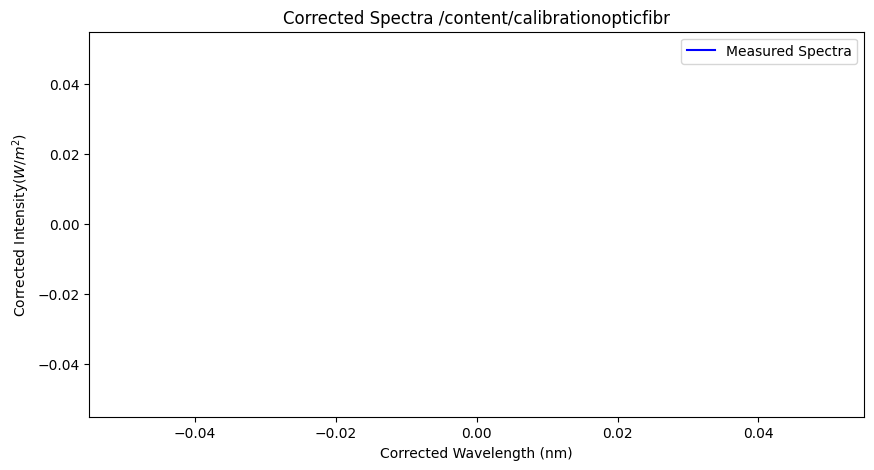

In [ ]:
#plots the corrected spectra

plt.figure(figsize=(10, 5))
plt.plot(Corrected_Wavelengths, Corrected_Intensities, color='b', label='Measured Spectra')
plt.title(f"Corrected Spectra {new_data_file[:-31]}")
plt.xlabel('Corrected Wavelength (nm)')
plt.ylabel(f"Corrected Intensity($W/m^2$)")
plt.legend()
#plt.savefig(f'corrected_spectra_{new_data_file[:-31]}.png')
plt.show()